In [1]:
import os, time, random
import numpy as np
import torch
import torch.nn as nn
import mlflow
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from torchvision import models, transforms
from torch.utils.data import DataLoader
from medmnist import ChestMNIST
from sklearn.metrics import (roc_auc_score, f1_score,
                             roc_curve, auc as sklearn_auc)
from tqdm import tqdm

import sys
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
os.chdir(PROJECT_ROOT)
sys.path.insert(0, PROJECT_ROOT)
print(f"Working dir: {os.getcwd()}")

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

LABEL_NAMES = [
    'Atelectasis','Cardiomegaly','Effusion','Infiltration','Mass','Nodule',
    'Pneumonia','Pneumothorax','Consolidation','Edema','Emphysema',
    'Fibrosis','Pleural_Thickening','Hernia'
]
NUM_CLASSES = 14

# W2 baseline per-class AUC (from your W2 notebook Cell 11)
W2_AUC_MV2  = [0.8143,0.7566,0.7445,0.7407,0.7254,0.7106,
                0.6938,0.6810,0.6723,0.6469,0.6346,0.6118,0.5814,0.5787]
W2_AUC_RN18 = [0.8192,0.7521,0.7320,0.7301,0.7132,0.7052,
                0.6940,0.6731,0.6716,0.6367,0.6342,0.6315,0.6228,0.5947]
W2_MACRO_MV2  = 0.6852
W2_MACRO_RN18 = 0.6865

# Yang et al. SOTA per-class AUC (from your W2 notebook Cell 16)
SOTA_AUC = {
    'Atelectasis':0.733,'Cardiomegaly':0.849,'Effusion':0.832,
    'Infiltration':0.702,'Mass':0.736,'Nodule':0.669,'Pneumonia':0.694,
    'Pneumothorax':0.799,'Consolidation':0.734,'Edema':0.851,
    'Emphysema':0.823,'Fibrosis':0.745,'Pleural_Thickening':0.706,'Hernia':0.917
}
SOTA_MACRO = np.mean(list(SOTA_AUC.values()))

device = torch.device('cpu')   # evaluation only — CPU is fine
print("Setup done ✓")

d:\Studies\2CS\S2\MLA\Amal's\medical_mlops\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Working dir: d:\Studies\2CS\S2\MLA\Amal's\medical_mlops
Setup done ✓


In [2]:
mlflow.set_tracking_uri(f"sqlite:///{PROJECT_ROOT}/experiments/mlflow.db")
mlflow.set_experiment("mlops-chestmnist")
print(f"MLflow DB: {PROJECT_ROOT}/experiments/mlflow.db")
print("MLflow ready ✓")

MLflow DB: d:\Studies\2CS\S2\MLA\Amal's\medical_mlops/experiments/mlflow.db
MLflow ready ✓


In [3]:
mlflow.set_experiment("mlops-chestmnist")

<Experiment: artifact_location='/content/mlruns/1', creation_time=1779559525369, experiment_id='1', last_update_time=1779559525369, lifecycle_stage='active', name='mlops-chestmnist', tags={}, trace_location=None, workspace='default'>

In [4]:
def get_transforms():
    return transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5]),
    ])

val_ds  = ChestMNIST(split="val",  transform=get_transforms(), download=True)
test_ds = ChestMNIST(split="test", transform=get_transforms(), download=True)

val_loader  = DataLoader(val_ds,  batch_size=64, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=0)

y_train    = ChestMNIST(split="train", download=True).labels.astype(np.float32)
pos_counts = y_train.sum(axis=0)
neg_counts = len(y_train) - pos_counts
pos_weight = torch.tensor(neg_counts / np.maximum(pos_counts, 1), dtype=torch.float32)

os.makedirs("figures", exist_ok=True)
print(f"Val: {len(val_ds):,} | Test: {len(test_ds):,}")

Val: 11,219 | Test: 22,433


In [5]:
class GrayscaleTo3Ch(nn.Module):
    def forward(self, x):
        return x.expand(-1, 3, -1, -1)

def load_model(backbone, ckpt_path):
    if backbone == 'mobilenet_v2':
        m = models.mobilenet_v2(weights=None)
        m.classifier = nn.Linear(m.classifier[1].in_features, NUM_CLASSES)
    else:
        m = models.resnet18(weights=None)
        m.fc = nn.Linear(m.fc.in_features, NUM_CLASSES)
    model = nn.Sequential(GrayscaleTo3Ch(), m)
    model.load_state_dict(torch.load(ckpt_path, map_location=device))
    model.eval()
    print(f"Loaded {backbone} from {ckpt_path} ✓")
    return model

mv2_model  = load_model('mobilenet_v2', 'models/mobilenet_v2_finetuned_best.pth')
rn18_model = load_model('resnet18',     'models/resnet18_finetuned_best.pth')

Loaded mobilenet_v2 from models/mobilenet_v2_finetuned_best.pth ✓
Loaded resnet18 from models/resnet18_finetuned_best.pth ✓


In [6]:
@torch.no_grad()
def get_probs_and_labels(model, loader):
    all_probs, all_labels = [], []
    for x, y in tqdm(loader, leave=False):
        logits = model(x.to(device))
        all_probs.append(torch.sigmoid(logits).cpu().numpy())
        all_labels.append(y.numpy())
    return np.vstack(all_probs), np.vstack(all_labels)

# Val set — needed for threshold tuning
val_probs_mv2,  val_labels  = get_probs_and_labels(mv2_model,  val_loader)
val_probs_rn18, _           = get_probs_and_labels(rn18_model, val_loader)

# Test set — final evaluation
test_probs_mv2,  test_labels = get_probs_and_labels(mv2_model,  test_loader)
test_probs_rn18, _           = get_probs_and_labels(rn18_model, test_loader)

print("Inference done ✓")

Inference done ✓


In [7]:
def compute_per_class_auc(probs, labels):
    return [
        roc_auc_score(labels[:, i], probs[:, i])
        if labels[:, i].sum() > 0 else float('nan')
        for i in range(NUM_CLASSES)
    ]

test_auc_mv2  = compute_per_class_auc(test_probs_mv2,  test_labels)
test_auc_rn18 = compute_per_class_auc(test_probs_rn18, test_labels)

print(f"\n{'Label':<22} {'W2 MV2':>7} {'W3 MV2':>7} {'W2 RN18':>8} {'W3 RN18':>8}")
print("-" * 57)
for i, name in enumerate(LABEL_NAMES):
    print(f"{name:<22} {W2_AUC_MV2[i]:>7.4f} {test_auc_mv2[i]:>7.4f} "
          f"{W2_AUC_RN18[i]:>8.4f} {test_auc_rn18[i]:>8.4f}")
print("-" * 57)
print(f"{'Macro-AUC':<22} {W2_MACRO_MV2:>7.4f} {np.nanmean(test_auc_mv2):>7.4f} "
      f"{W2_MACRO_RN18:>8.4f} {np.nanmean(test_auc_rn18):>8.4f}")


Label                   W2 MV2  W3 MV2  W2 RN18  W3 RN18
---------------------------------------------------------
Atelectasis             0.8143  0.7726   0.8192   0.7745
Cardiomegaly            0.7566  0.8919   0.7521   0.8930
Effusion                0.7445  0.8445   0.7320   0.8510
Infiltration            0.7407  0.6809   0.7301   0.6829
Mass                    0.7254  0.7739   0.7132   0.7545
Nodule                  0.7106  0.6668   0.7052   0.6550
Pneumonia               0.6938  0.7228   0.6940   0.7163
Pneumothorax            0.6810  0.8281   0.6731   0.8210
Consolidation           0.6723  0.7844   0.6716   0.7823
Edema                   0.6469  0.8718   0.6367   0.8672
Emphysema               0.6346  0.8255   0.6342   0.8178
Fibrosis                0.6118  0.7726   0.6315   0.7658
Pleural_Thickening      0.5814  0.7415   0.6228   0.7306
Hernia                  0.5787  0.9113   0.5947   0.9272
---------------------------------------------------------
Macro-AUC               0.68

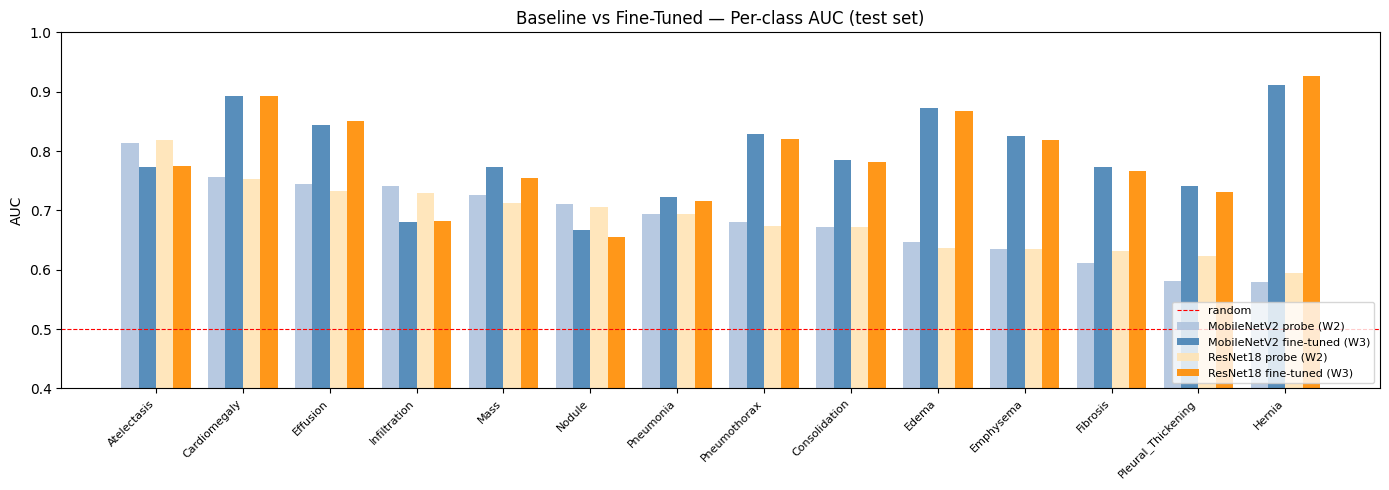

In [8]:
x     = np.arange(NUM_CLASSES)
width = 0.2

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - 1.5*width, W2_AUC_MV2,       width, label='MobileNetV2 probe (W2)',       color='lightsteelblue', alpha=0.9)
ax.bar(x - 0.5*width, test_auc_mv2,      width, label='MobileNetV2 fine-tuned (W3)',  color='steelblue',      alpha=0.9)
ax.bar(x + 0.5*width, W2_AUC_RN18,       width, label='ResNet18 probe (W2)',          color='moccasin',       alpha=0.9)
ax.bar(x + 1.5*width, test_auc_rn18,     width, label='ResNet18 fine-tuned (W3)',     color='darkorange',     alpha=0.9)
ax.axhline(0.5, color='red', linestyle='--', linewidth=0.8, label='random')
ax.set_xticks(x)
ax.set_xticklabels(LABEL_NAMES, rotation=45, ha='right', fontsize=8)
ax.set_ylabel("AUC"); ax.set_ylim(0.4, 1.0)
ax.set_title("Baseline vs Fine-Tuned — Per-class AUC (test set)")
ax.legend(fontsize=8, loc='lower right')
plt.tight_layout()
plt.savefig("figures/eval_baseline_vs_finetuned_auc.png", dpi=150)
plt.show()

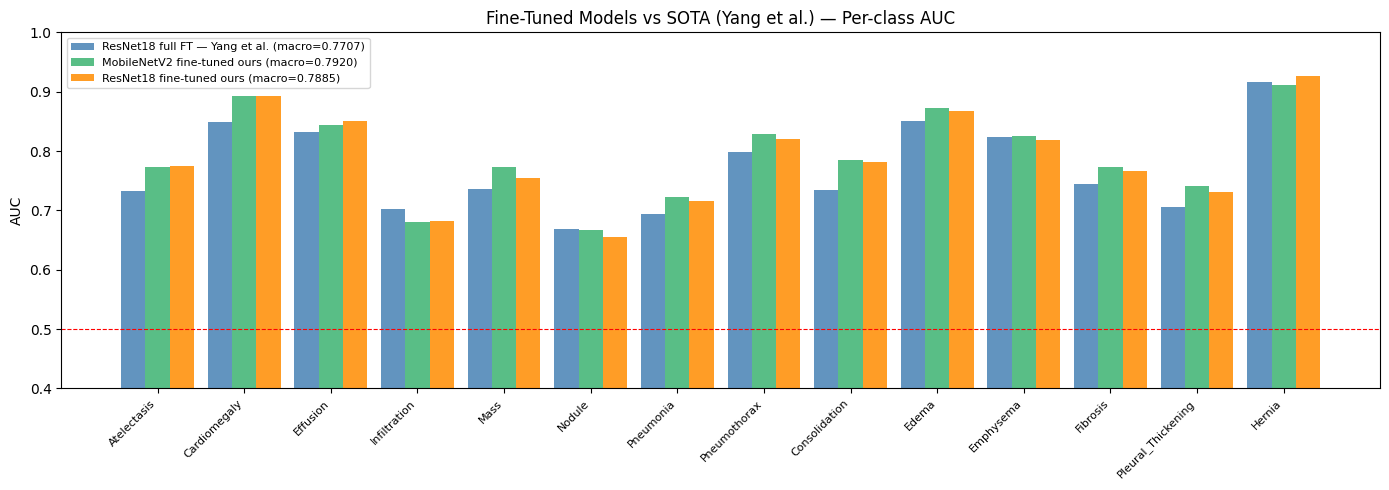

In [9]:
sota_vals = [SOTA_AUC[n] for n in LABEL_NAMES]
x = np.arange(NUM_CLASSES)
width = 0.28

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - width, sota_vals,       width, label=f'ResNet18 full FT — Yang et al. (macro={SOTA_MACRO:.4f})', color='steelblue',    alpha=0.85)
ax.bar(x,         test_auc_mv2,   width, label=f'MobileNetV2 fine-tuned ours (macro={np.nanmean(test_auc_mv2):.4f})',  color='mediumseagreen', alpha=0.85)
ax.bar(x + width, test_auc_rn18,  width, label=f'ResNet18 fine-tuned ours (macro={np.nanmean(test_auc_rn18):.4f})',   color='darkorange',     alpha=0.85)
ax.axhline(0.5, color='red', linestyle='--', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(LABEL_NAMES, rotation=45, ha='right', fontsize=8)
ax.set_ylabel("AUC"); ax.set_ylim(0.4, 1.0)
ax.set_title("Fine-Tuned Models vs SOTA (Yang et al.) — Per-class AUC")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("figures/eval_finetuned_vs_sota.png", dpi=150)
plt.show()

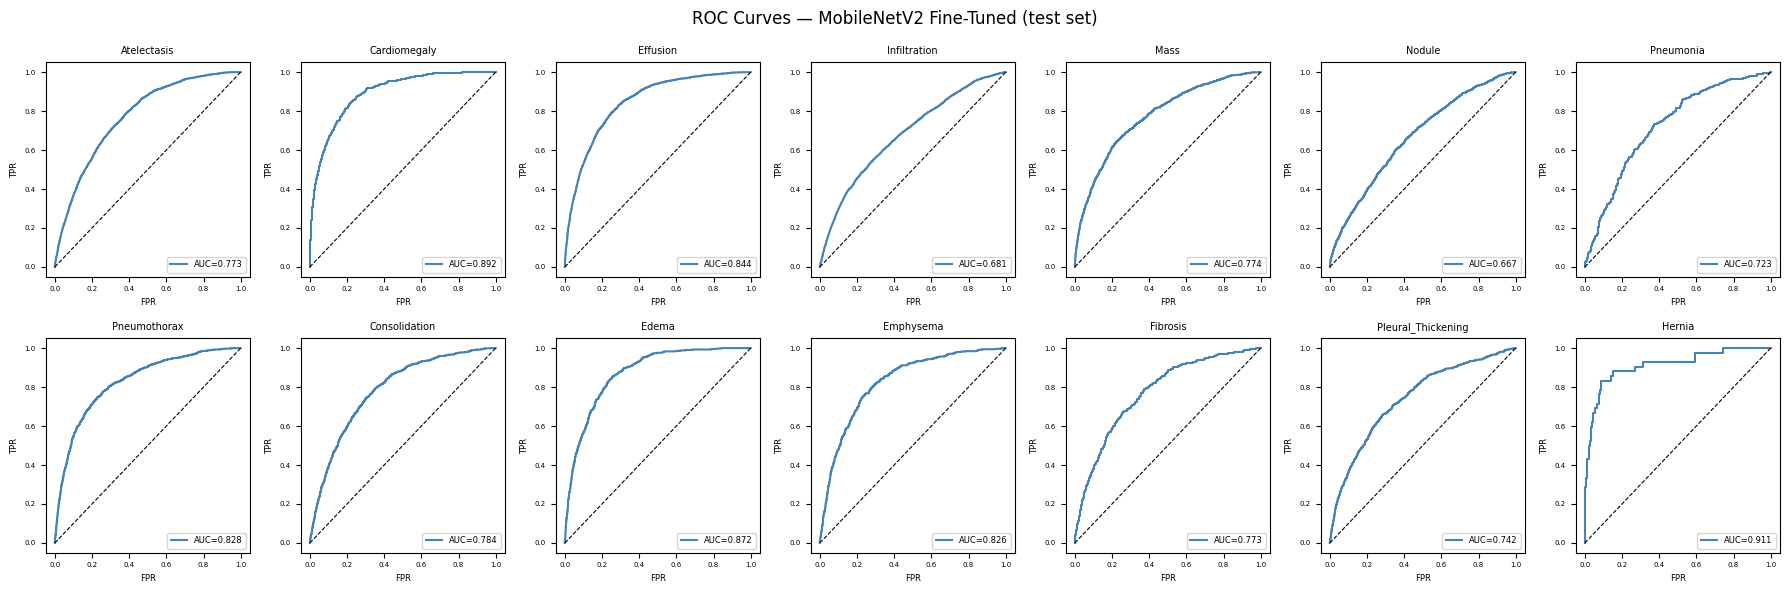

In [10]:
fig, axes = plt.subplots(2, 7, figsize=(18, 6))
axes = axes.flat

for i, (name, ax) in enumerate(zip(LABEL_NAMES, axes)):
    if test_labels[:, i].sum() > 0:
        fpr, tpr, _ = roc_curve(test_labels[:, i], test_probs_mv2[:, i])
        roc_auc     = sklearn_auc(fpr, tpr)
        ax.plot(fpr, tpr, color='steelblue', lw=1.5, label=f'AUC={roc_auc:.3f}')
    ax.plot([0,1],[0,1],'k--',lw=0.8)
    ax.set_title(name, fontsize=7)
    ax.legend(fontsize=6, loc='lower right')
    ax.set_xlabel("FPR", fontsize=6); ax.set_ylabel("TPR", fontsize=6)
    ax.tick_params(labelsize=5)

plt.suptitle("ROC Curves — MobileNetV2 Fine-Tuned (test set)", fontsize=12)
plt.tight_layout()
plt.savefig("figures/eval_roc_curves_mv2.png", dpi=150)
plt.show()

In [11]:
# Tune thresholds on VAL set, evaluate on TEST set
THRESHOLDS = np.arange(0.1, 0.91, 0.05)

def tune_thresholds(val_probs, val_labels):
    best_thresholds = []
    for i in range(NUM_CLASSES):
        best_t, best_f1 = 0.5, 0.0
        for t in THRESHOLDS:
            preds = (val_probs[:, i] >= t).astype(int)
            f1 = f1_score(val_labels[:, i], preds, zero_division=0)
            if f1 > best_f1:
                best_f1, best_t = f1, t
        best_thresholds.append(best_t)
    return np.array(best_thresholds)

tuned_t_mv2  = tune_thresholds(val_probs_mv2,  val_labels)
tuned_t_rn18 = tune_thresholds(val_probs_rn18, val_labels)

# Evaluate on test set with both threshold strategies
def eval_with_thresholds(probs, labels, thresholds):
    preds = (probs >= thresholds).astype(int)
    return f1_score(labels, preds, average='macro', zero_division=0)

f1_fixed_mv2  = eval_with_thresholds(test_probs_mv2,  test_labels, 0.5)
f1_tuned_mv2  = eval_with_thresholds(test_probs_mv2,  test_labels, tuned_t_mv2)
f1_fixed_rn18 = eval_with_thresholds(test_probs_rn18, test_labels, 0.5)
f1_tuned_rn18 = eval_with_thresholds(test_probs_rn18, test_labels, tuned_t_rn18)

print("ABLATION 1 — Threshold tuning")
print(f"\n{'Model':<25} {'F1 @ 0.5':>10} {'F1 tuned':>10} {'Delta':>8}")
print("-" * 56)
print(f"{'MobileNetV2 fine-tuned':<25} {f1_fixed_mv2:>10.4f} {f1_tuned_mv2:>10.4f} {f1_tuned_mv2-f1_fixed_mv2:>+8.4f}")
print(f"{'ResNet18 fine-tuned':<25} {f1_fixed_rn18:>10.4f} {f1_tuned_rn18:>10.4f} {f1_tuned_rn18-f1_fixed_rn18:>+8.4f}")

print(f"\nTuned thresholds — MobileNetV2:")
for name, t in zip(LABEL_NAMES, tuned_t_mv2):
    print(f"  {name:<22}: {t:.2f}")

ABLATION 1 — Threshold tuning

Model                       F1 @ 0.5   F1 tuned    Delta
--------------------------------------------------------
MobileNetV2 fine-tuned        0.1898     0.2360  +0.0462
ResNet18 fine-tuned           0.1877     0.2331  +0.0454

Tuned thresholds — MobileNetV2:
  Atelectasis           : 0.70
  Cardiomegaly          : 0.90
  Effusion              : 0.65
  Infiltration          : 0.55
  Mass                  : 0.80
  Nodule                : 0.60
  Pneumonia             : 0.85
  Pneumothorax          : 0.80
  Consolidation         : 0.75
  Edema                 : 0.90
  Emphysema             : 0.80
  Fibrosis              : 0.75
  Pleural_Thickening    : 0.75
  Hernia                : 0.90


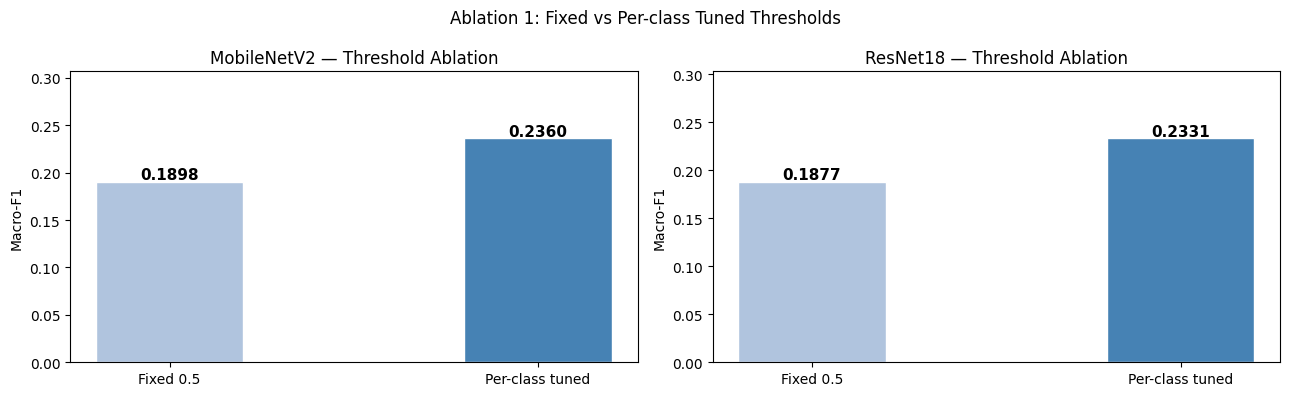

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, (model_name, fixed, tuned, thresholds) in zip(axes, [
    ('MobileNetV2', f1_fixed_mv2, f1_tuned_mv2, tuned_t_mv2),
    ('ResNet18',    f1_fixed_rn18, f1_tuned_rn18, tuned_t_rn18),
]):
    ax.bar(['Fixed 0.5', 'Per-class tuned'], [fixed, tuned],
           color=['lightsteelblue', 'steelblue'], edgecolor='white', width=0.4)
    ax.set_ylim(0, max(fixed, tuned) * 1.3)
    ax.set_ylabel("Macro-F1")
    ax.set_title(f"{model_name} — Threshold Ablation")
    for j, v in enumerate([fixed, tuned]):
        ax.text(j, v + 0.003, f"{v:.4f}", ha='center', fontsize=11, fontweight='bold')

plt.suptitle("Ablation 1: Fixed vs Per-class Tuned Thresholds", fontsize=12)
plt.tight_layout()
plt.savefig("figures/ablation_threshold_tuning.png", dpi=150)
plt.show()

In [13]:
import time

def benchmark_latency(model, n_warmup=10, n_runs=200):
    """Single image and batch latency on CPU."""
    dummy_single = torch.randn(1,  1, 224, 224)
    dummy_batch  = torch.randn(32, 1, 224, 224)

    model.eval()
    with torch.no_grad():
        # Warmup
        for _ in range(n_warmup):
            model(dummy_single)

        # Single image
        t0 = time.perf_counter()
        for _ in range(n_runs):
            model(dummy_single)
        ms_single = (time.perf_counter() - t0) / n_runs * 1000

        # Batch of 32
        t0 = time.perf_counter()
        for _ in range(n_runs):
            model(dummy_batch)
        ms_batch = (time.perf_counter() - t0) / n_runs * 1000

    return ms_single, ms_batch

ms_single_mv2,  ms_batch_mv2  = benchmark_latency(mv2_model)
ms_single_rn18, ms_batch_rn18 = benchmark_latency(rn18_model)

params_mv2  = sum(p.numel() for p in mv2_model.parameters())
params_rn18 = sum(p.numel() for p in rn18_model.parameters())

print("ABLATION 2 — Latency Benchmark (CPU, 200 runs)")
print(f"\n{'Model':<25} {'Params':>10} {'ms/image':>10} {'ms/batch32':>12} {'Test AUC':>10}")
print("-" * 70)
print(f"{'MobileNetV2 fine-tuned':<25} {params_mv2:>10,} {ms_single_mv2:>10.2f} {ms_batch_mv2:>12.2f} {np.nanmean(test_auc_mv2):>10.4f}")
print(f"{'ResNet18 fine-tuned':<25} {params_rn18:>10,} {ms_single_rn18:>10.2f} {ms_batch_rn18:>12.2f} {np.nanmean(test_auc_rn18):>10.4f}")

ABLATION 2 — Latency Benchmark (CPU, 200 runs)

Model                         Params   ms/image   ms/batch32   Test AUC
----------------------------------------------------------------------
MobileNetV2 fine-tuned     2,241,806      58.59      1439.60     0.7920
ResNet18 fine-tuned       11,183,694      87.33      1820.37     0.7885


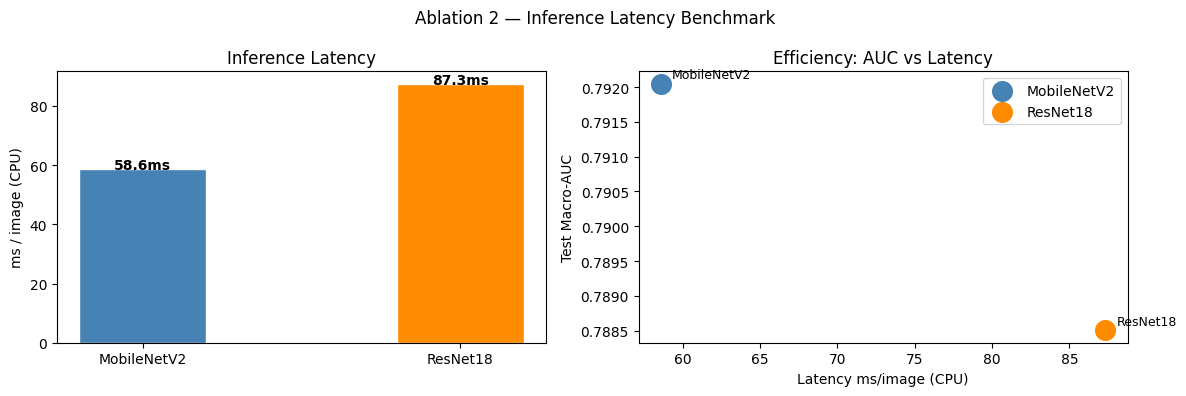

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

models_names = ['MobileNetV2', 'ResNet18']
latencies    = [ms_single_mv2, ms_single_rn18]
aucs         = [np.nanmean(test_auc_mv2), np.nanmean(test_auc_rn18)]
colors       = ['steelblue', 'darkorange']

# Left: latency bar
axes[0].bar(models_names, latencies, color=colors, width=0.4, edgecolor='white')
axes[0].set_ylabel("ms / image (CPU)")
axes[0].set_title("Inference Latency")
for i, v in enumerate(latencies):
    axes[0].text(i, v + 0.2, f"{v:.1f}ms", ha='center', fontweight='bold')

# Right: AUC vs latency scatter
for i, (name, lat, a, c) in enumerate(zip(models_names, latencies, aucs, colors)):
    axes[1].scatter(lat, a, s=200, color=c, zorder=5, label=name)
    axes[1].annotate(name, (lat, a), textcoords="offset points",
                     xytext=(8, 4), fontsize=9)
axes[1].set_xlabel("Latency ms/image (CPU)")
axes[1].set_ylabel("Test Macro-AUC")
axes[1].set_title("Efficiency: AUC vs Latency")
axes[1].legend()

plt.suptitle("Ablation 2 — Inference Latency Benchmark", fontsize=12)
plt.tight_layout()
plt.savefig("figures/ablation_latency_benchmark.png", dpi=150)
plt.show()

In [15]:
with mlflow.start_run(run_name="W3_evaluation_ablations"):
    # Threshold ablation
    mlflow.log_metrics({
        'mv2_f1_fixed_threshold':  f1_fixed_mv2,
        'mv2_f1_tuned_threshold':  f1_tuned_mv2,
        'rn18_f1_fixed_threshold': f1_fixed_rn18,
        'rn18_f1_tuned_threshold': f1_tuned_rn18,
    })
    # Latency
    mlflow.log_metrics({
        'mv2_latency_ms_single':   ms_single_mv2,
        'mv2_latency_ms_batch32':  ms_batch_mv2,
        'rn18_latency_ms_single':  ms_single_rn18,
        'rn18_latency_ms_batch32': ms_batch_rn18,
    })
    # Final test AUC
    mlflow.log_metrics({
        'mv2_test_macro_auc':  np.nanmean(test_auc_mv2),
        'rn18_test_macro_auc': np.nanmean(test_auc_rn18),
    })
    # Tuned thresholds as params
    for name, t in zip(LABEL_NAMES, tuned_t_mv2):
        mlflow.log_param(f'mv2_threshold_{name}', round(float(t), 2))

    mlflow.log_artifacts("figures")
    print("All ablation results logged to MLflow ✓")

All ablation results logged to MLflow ✓


In [16]:
print("=" * 75)
print("FULL RESULTS SUMMARY — W3 Experiments")
print("=" * 75)

print(f"\n{'Model':<28} {'Strategy':<18} {'Macro-AUC':>10} {'F1@0.5':>8} {'F1 tuned':>10}")
print("-" * 75)
print(f"{'MobileNetV2':<28} {'Linear probe':<18} {W2_MACRO_MV2:>10.4f} {'0.1333':>8} {'—':>10}")
print(f"{'ResNet18':<28} {'Linear probe':<18} {W2_MACRO_RN18:>10.4f} {'0.1378':>8} {'—':>10}")
print(f"{'MobileNetV2':<28} {'Full fine-tune':<18} {np.nanmean(test_auc_mv2):>10.4f} {f1_fixed_mv2:>8.4f} {f1_tuned_mv2:>10.4f}")
print(f"{'ResNet18':<28} {'Full fine-tune':<18} {np.nanmean(test_auc_rn18):>10.4f} {f1_fixed_rn18:>8.4f} {f1_tuned_rn18:>10.4f}")
print(f"{'Yang et al. (SOTA)':<28} {'Full fine-tune':<18} {SOTA_MACRO:>10.4f} {'—':>8} {'—':>10}")

print(f"\n{'Model':<28} {'Params':>12} {'ms/img':>8} {'ms/batch32':>12}")
print("-" * 63)
print(f"{'MobileNetV2 fine-tuned':<28} {params_mv2:>12,} {ms_single_mv2:>8.1f} {ms_batch_mv2:>12.1f}")
print(f"{'ResNet18 fine-tuned':<28} {params_rn18:>12,} {ms_single_rn18:>8.1f} {ms_batch_rn18:>12.1f}")
print("=" * 75)

FULL RESULTS SUMMARY — W3 Experiments

Model                        Strategy            Macro-AUC   F1@0.5   F1 tuned
---------------------------------------------------------------------------
MobileNetV2                  Linear probe           0.6852   0.1333          —
ResNet18                     Linear probe           0.6865   0.1378          —
MobileNetV2                  Full fine-tune         0.7920   0.1898     0.2360
ResNet18                     Full fine-tune         0.7885   0.1877     0.2331
Yang et al. (SOTA)           Full fine-tune         0.7707        —          —

Model                              Params   ms/img   ms/batch32
---------------------------------------------------------------
MobileNetV2 fine-tuned          2,241,806     58.6       1439.6
ResNet18 fine-tuned            11,183,694     87.3       1820.4


In [17]:
client = mlflow.tracking.MlflowClient()
for exp in client.search_experiments():
    print(f"\n{exp.name} (id={exp.experiment_id})")
    for run in client.search_runs([exp.experiment_id]):
        print(f"  └─ {run.info.run_name:<35} | {run.info.status} | "
              f"test_auc={run.data.metrics.get('test_macro_auc','N/A')}")


mlops-chestmnist (id=1)
  └─ W3_evaluation_ablations             | FINISHED | test_auc=N/A
  └─ resnet18_finetuned                  | FINISHED | test_auc=0.7819511438219608
  └─ mobilenet_v2_finetuned              | FINISHED | test_auc=0.7899971106981162
  └─ resnet18_linear_probe               | FINISHED | test_auc=0.6864705914031991
  └─ mobilenet_v2_linear_probe           | FINISHED | test_auc=0.6851970365742596

Default (id=0)
